# 03 — Evaluation: Layer 2 (Macro Topic) Classifier

| | |
|---|---|
| **Project** | Public Pulse |
| **Pipeline stage** | Layer 2 (Macro Topic) |
| **Notebook role** | Final evaluation only — the FIRST and ONLY time `test.csv` is used |
| **Owner** | Thrithwaka |
| **Upstream input** | `models/layer2_topic/checkpoints/best_model/` (from `02_training.ipynb`), `data/splits/layer2/test.csv` (from `01_data_preparation.ipynb`) |
| **Environment** | Google Colab, project on Google Drive |
| **Random seed** | 42 |

## Purpose

Produces the project's final, reportable performance numbers for Layer 2 (Macro Topic) against
the held-out test set. This is the merged 5-class taxonomy (TOPIC_ECON_SERV combines the original TOPIC_ECON and TOPIC_SERV) -- a documented scope decision from 01_data_preparation.ipynb, not a bug if you see only 5 classes here instead of 6.

**This test set has not been touched by any other notebook.** If any number here looks
suspiciously better than the validation sanity check in `02_training.ipynb`, that is a
signal to investigate for a data leak, not a result to celebrate uncritically.

## How to Read This Notebook

No claim of 100% accuracy is made. Every class's precision/recall/F1 is reported
individually — aggregate accuracy alone is not treated as sufficient evidence of a
working model anywhere in this project.

## 1. Google Colab Setup — Environment & Google Drive

In [1]:
!pip uninstall -y torchvision torchaudio -q
!pip install -q transformers==4.53.0 datasets accelerate sentencepiece "scikit-learn>=1.4"
print("Install complete. REQUIRED: Runtime -> Restart session, then Runtime -> Run all.")

Install complete. REQUIRED: Runtime -> Restart session, then Runtime -> Run all.


**Stop here and restart the runtime now**, then **Runtime → Run all**.

In [2]:
import torch
import transformers

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
assert transformers.__version__ == "4.53.0", "Did you Restart session after the install cell?"

from transformers import AutoTokenizer, AutoModelForSequenceClassification
print("Core imports successful.")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("\nDevice:", device, "(GPU optional for evaluation -- inference is far lighter than training)")

torch: 2.11.0+cu128
transformers: 4.53.0
Core imports successful.

Device: cuda (GPU optional for evaluation -- inference is far lighter than training)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT = Path("/content/drive/MyDrive/public-pulse-srilanka")
assert PROJECT_ROOT.exists(), f"Project folder not found at {PROJECT_ROOT}."
print("Project root:", PROJECT_ROOT.resolve())

Mounted at /content/drive
Project root: /content/drive/MyDrive/public-pulse-srilanka


In [4]:
checkpoint_check = PROJECT_ROOT / "models" / "layer2_topic" / "checkpoints" / "best_model"
test_check = PROJECT_ROOT / "data" / "splits" / "layer2" / "test.csv"

print("Checkpoint exists:", checkpoint_check.exists())
print("test.csv exists:", test_check.exists())
if not checkpoint_check.exists() or not test_check.exists():
    print("WARNING: expected files missing -- confirm 01_data_preparation.ipynb and 02_training.ipynb both ran successfully.")

Checkpoint exists: True
test.csv exists: True


## 2. Setup & Configuration

In [5]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score

RANDOM_STATE = 42

MODEL_DIR = PROJECT_ROOT / "models" / "layer2_topic"
CHECKPOINT_DIR = MODEL_DIR / "checkpoints" / "best_model"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits" / "layer2"
RESULTS_CM_DIR = PROJECT_ROOT / "results" / "confusion_matrices"
RESULTS_REPORTS_DIR = PROJECT_ROOT / "results" / "classification_reports"
RESULTS_ERRORS_DIR = PROJECT_ROOT / "results" / "error_analysis"

for d in [RESULTS_CM_DIR, RESULTS_REPORTS_DIR, RESULTS_ERRORS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MAX_SEQ_LENGTH = 256

print("Checkpoint:", CHECKPOINT_DIR.resolve())
print("Test set:", SPLITS_DIR.resolve())

Checkpoint: /content/drive/MyDrive/public-pulse-srilanka/models/layer2_topic/checkpoints/best_model
Test set: /content/drive/MyDrive/public-pulse-srilanka/data/splits/layer2


## 3. Load Training Metadata

Read directly from what `02_training.ipynb` actually recorded — not re-assumed here —
so this notebook can't silently drift out of sync with what was actually trained.

In [6]:
with open(MODEL_DIR / "training_metadata.json") as f:
    training_metadata = json.load(f)

print(json.dumps(training_metadata, indent=2))

# Use the exact input column the model was trained on -- defaults to text_raw for
# checkpoints trained before the text_clean preprocessing fix (e.g. Layer 1)
MODEL_INPUT_COLUMN = training_metadata.get("model_input_column", "text_raw")
print(f"\nModel input column: '{MODEL_INPUT_COLUMN}'")

{
  "base_model": "xlm-roberta-base",
  "num_labels": 5,
  "labels": [
    "TOPIC_ECON_SERV",
    "TOPIC_FOR",
    "TOPIC_GOV",
    "TOPIC_LAW",
    "TOPIC_MEDIA"
  ],
  "max_seq_length": 256,
  "model_input_column": "text_clean",
  "best_metric": "f1_macro",
  "best_metric_value": 0.7050123837778992,
  "class_weights_used": {
    "TOPIC_ECON_SERV": 3.0165,
    "TOPIC_FOR": 3.0165,
    "TOPIC_GOV": 0.2722,
    "TOPIC_LAW": 3.0165,
    "TOPIC_MEDIA": 3.0165
  },
  "taxonomy_note": "5-class merged taxonomy (TOPIC_ECON+TOPIC_SERV -> TOPIC_ECON_SERV), documented scope decision -- see 01_data_preparation.ipynb Section 9",
  "random_seed": 42,
  "train_rows": 6033,
  "val_rows": 1153
}

Model input column: 'text_clean'


## 4. Load the Promoted Checkpoint

In [7]:
with open(MODEL_DIR / "label_map.json") as f:
    label2id = json.load(f)
id2label = {v: k for k, v in label2id.items()}

LABELS = [id2label[i] for i in range(len(id2label))]
print("Labels (index order):", LABELS)
assert len(LABELS) == 5, f"Expected 5 classes, found {len(LABELS)}"

tokenizer = AutoTokenizer.from_pretrained(str(CHECKPOINT_DIR))
model = AutoModelForSequenceClassification.from_pretrained(str(CHECKPOINT_DIR))
model.to(device)
model.eval()

print(f"\nCheckpoint loaded on {device}, {model.num_parameters():,} parameters")

Labels (index order): ['TOPIC_ECON_SERV', 'TOPIC_FOR', 'TOPIC_GOV', 'TOPIC_LAW', 'TOPIC_MEDIA']

Checkpoint loaded on cuda, 278,047,493 parameters


## 5. Load the Held-Out Test Set

**First and only use of this file in the entire pipeline.**

In [8]:
test_df = pd.read_csv(SPLITS_DIR / "test.csv")
print(f"Test set: {len(test_df)} rows")
print(test_df["layer2_topic_label"].value_counts())

assert MODEL_INPUT_COLUMN in test_df.columns, f"{MODEL_INPUT_COLUMN} not found in test.csv"
assert test_df["layer2_topic_label"].isna().sum() == 0, "Missing labels in test set"

# Final leakage safety net -- re-checked here even though 01_data_preparation.ipynb
# already verified this, given how many revisions this pipeline has been through
train_df_check = pd.read_csv(SPLITS_DIR / "train.csv")
overlap = set(test_df["comment_id"]) & set(train_df_check["comment_id"])
assert len(overlap) == 0, f"LEAKAGE: {len(overlap)} comment_ids appear in both train and test"
print("\nNo train/test leakage confirmed. Test set integrity verified.")

Test set: 1153 rows
layer2_topic_label
TOPIC_GOV          950
TOPIC_LAW           69
TOPIC_MEDIA         57
TOPIC_FOR           40
TOPIC_ECON_SERV     37
Name: count, dtype: int64

No train/test leakage confirmed. Test set integrity verified.


## 6. Run Predictions on the Test Set

In [9]:
import torch as _torch  # local alias not needed if already imported, kept for clarity

def predict_batch(texts, batch_size=32):
    all_preds = []
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        inputs = tokenizer(batch, truncation=True, max_length=MAX_SEQ_LENGTH, padding=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())
    return all_preds, all_probs

test_texts = test_df[MODEL_INPUT_COLUMN].astype(str).tolist()
test_labels_true = test_df["layer2_topic_label"].map(label2id).tolist()

test_preds, test_probs = predict_batch(test_texts)
test_confidences = [max(p) for p in test_probs]

print(f"Predictions complete: {len(test_preds)} rows")

Predictions complete: 1153 rows


## 7. Final Classification Report — Test Set

**This is the project's official, reportable result for this layer.**

In [10]:
report_dict = classification_report(
    test_labels_true, test_preds,
    labels=list(range(len(LABELS))), target_names=LABELS,
    output_dict=True, zero_division=0,
)
report_text = classification_report(
    test_labels_true, test_preds,
    labels=list(range(len(LABELS))), target_names=LABELS,
    zero_division=0,
)
print(report_text)

with open(RESULTS_REPORTS_DIR / "layer2_topic_test_classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)
print("Saved to:", RESULTS_REPORTS_DIR / "layer2_topic_test_classification_report.json")

                 precision    recall  f1-score   support

TOPIC_ECON_SERV       0.57      0.68      0.62        37
      TOPIC_FOR       0.58      0.53      0.55        40
      TOPIC_GOV       0.95      0.92      0.94       950
      TOPIC_LAW       0.67      0.84      0.75        69
    TOPIC_MEDIA       0.70      0.82      0.76        57

       accuracy                           0.89      1153
      macro avg       0.70      0.76      0.72      1153
   weighted avg       0.90      0.89      0.89      1153

Saved to: /content/drive/MyDrive/public-pulse-srilanka/results/classification_reports/layer2_topic_test_classification_report.json


## 8. Confusion Matrix — Test Set

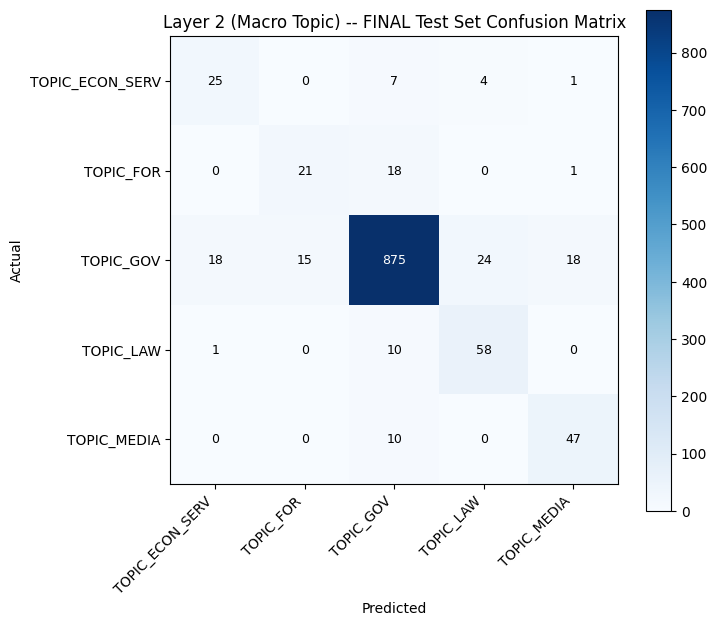

In [11]:
cm = confusion_matrix(test_labels_true, test_preds, labels=list(range(len(LABELS))))

fig, ax = plt.subplots(figsize=(max(6, len(LABELS)*1.5), max(5, len(LABELS)*1.3)))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Layer 2 (Macro Topic) -- FINAL Test Set Confusion Matrix")
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=9)
plt.colorbar(im)
plt.tight_layout()
plt.savefig(RESULTS_CM_DIR / "layer2_topic_test_confusion_matrix.png", dpi=150)
plt.show()

## 9. Test vs. Validation Comparison — Overfitting Check

If test macro-F1 is meaningfully *lower* than the validation macro-F1 recorded during
training, that's a sign the model (or the checkpoint-selection process) overfit to the
validation set. If test performance is similar or better, that's a healthy sign the model
generalizes.

In [12]:
test_f1_macro = f1_score(test_labels_true, test_preds, average="macro", zero_division=0)
val_f1_macro = training_metadata.get("best_metric_value")

print(f"Validation macro-F1 (from training): {val_f1_macro:.4f}" if val_f1_macro else "Validation macro-F1 not found in metadata")
print(f"Test macro-F1 (this notebook):       {test_f1_macro:.4f}")

if val_f1_macro:
    gap = val_f1_macro - test_f1_macro
    print(f"\nGap (val - test): {gap:.4f}")
    if gap > 0.05:
        print("NOTE: Test performance is notably lower than validation -- worth investigating")
        print("whether checkpoint selection overfit to the validation set.")
    else:
        print("Gap is small -- no strong evidence of overfitting to the validation set.")

Validation macro-F1 (from training): 0.7050
Test macro-F1 (this notebook):       0.7224

Gap (val - test): -0.0174
Gap is small -- no strong evidence of overfitting to the validation set.


## 10. Error Analysis — Sample Misclassifications

Qualitative inspection of actual errors, not just aggregate numbers — often more useful
for deciding what to fix next than the confusion matrix alone.

In [13]:
test_df_results = test_df.copy()
test_df_results["predicted_label"] = [id2label[p] for p in test_preds]
test_df_results["confidence"] = test_confidences
test_df_results["correct"] = test_df_results["layer2_topic_label"] == test_df_results["predicted_label"]

errors_df = test_df_results[~test_df_results["correct"]].sort_values("confidence", ascending=False)
print(f"Total errors: {len(errors_df)} / {len(test_df_results)} ({len(errors_df)/len(test_df_results)*100:.1f}%)")
print()
print("Highest-confidence WRONG predictions (most concerning -- model was confidently incorrect):")
display_cols = ["layer2_topic_label", "predicted_label", "confidence", MODEL_INPUT_COLUMN]
print(errors_df[display_cols].head(10).to_string())

errors_df.to_csv(RESULTS_ERRORS_DIR / "layer2_topic_test_errors.csv", index=False)
print("\nFull error list saved to:", RESULTS_ERRORS_DIR / "layer2_topic_test_errors.csv")

Total errors: 127 / 1153 (11.0%)

Highest-confidence WRONG predictions (most concerning -- model was confidently incorrect):
     layer2_topic_label  predicted_label  confidence                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

### 10.1 Errors vs. Pre-Merge Original Labels

**Conditional check:** only runs if `layer2_topic_label_original` was preserved in `test.csv`. This
column isn't currently saved by `01_data_preparation.ipynb` (it's dropped during feature
selection) — if this cell reports it missing, that's expected, not a bug. Preserving it
in a future data-prep revision would let this cell show whether errors specifically
cluster around the classes merged away (directly informing v2 planning).

In [14]:
if "layer2_topic_label_original" in test_df.columns:
    test_df_results["layer2_topic_label_original"] = test_df["layer2_topic_label_original"]
    print(pd.crosstab(test_df_results["layer2_topic_label_original"], test_df_results["correct"]))
else:
    print(f"'layer2_topic_label_original' not present in test.csv -- this diagnostic is skipped.")
    print("To enable it, add it to the feature_cols allowlist in 01_data_preparation.ipynb's split step.")

'layer2_topic_label_original' not present in test.csv -- this diagnostic is skipped.
To enable it, add it to the feature_cols allowlist in 01_data_preparation.ipynb's split step.


## 11. Notebook Summary

### What was done
1. Loaded the promoted checkpoint and confirmed the model input column matches what it
   was actually trained on -- read from `training_metadata.json`, not assumed
2. Loaded the untouched test set and re-verified no train/test leakage
3. Ran predictions and produced the project's official test-set classification report
4. Built the final confusion matrix
5. Compared test vs. validation macro-F1 to check for overfitting during checkpoint selection
6. Extracted and saved the highest-confidence misclassifications for qualitative review

7. Checked (if available) whether errors cluster around the pre-merge TOPIC_ECON vs TOPIC_SERV distinction, informing whether unmerging is worth prioritizing in v2

### Outputs produced
| File | Contents |
|---|---|
| `results/classification_reports/layer2_topic_test_classification_report.json` | Official per-class precision/recall/F1 |
| `results/confusion_matrices/layer2_topic_test_confusion_matrix.png` | Final confusion matrix |
| `results/error_analysis/layer2_topic_test_errors.csv` | All misclassified test rows, sorted by confidence |

## 12. Handover Notes

This checkpoint (`models/layer2_topic/checkpoints/best_model/`) should be wired into the
inference cascade to run on any comment Layer 1 marks `VALID`. Report all 5 classes'
per-class F1 in the project presentation, not just the macro average — `TOPIC_GOV`
dominance means the macro number alone doesn't tell the full story.